<a href="https://colab.research.google.com/github/ndanilova/Data_Analysis/blob/main/lab2/data_analysis_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Современные инструменты анализа данных.
### Лабораторная работа №2: Кластеризация данных.
#### Студент: Данилова Анастасия Алексеевна СИАД K33 1.2

КЛАСТЕРИЗАЦИЯ НА СГЕНЕРИРОВАННЫХ ДАННЫХ 

СОЗДАНИЕ НАБОРА ДАННЫХ
Размерность данных: (300, 2)
Количество истинных кластеров: 4

ПРИМЕНЕНИЕ МЕТОДА K-MEANS
Подбор оптимального числа кластеров...
K=2: inertia=9051.82, silhouette=0.615
K=3: inertia=1773.74, silhouette=0.799
K=4: inertia=203.89, silhouette=0.876
K=5: inertia=184.41, silhouette=0.755
K=6: inertia=165.72, silhouette=0.610
K=7: inertia=148.07, silhouette=0.454
K=8: inertia=129.73, silhouette=0.341


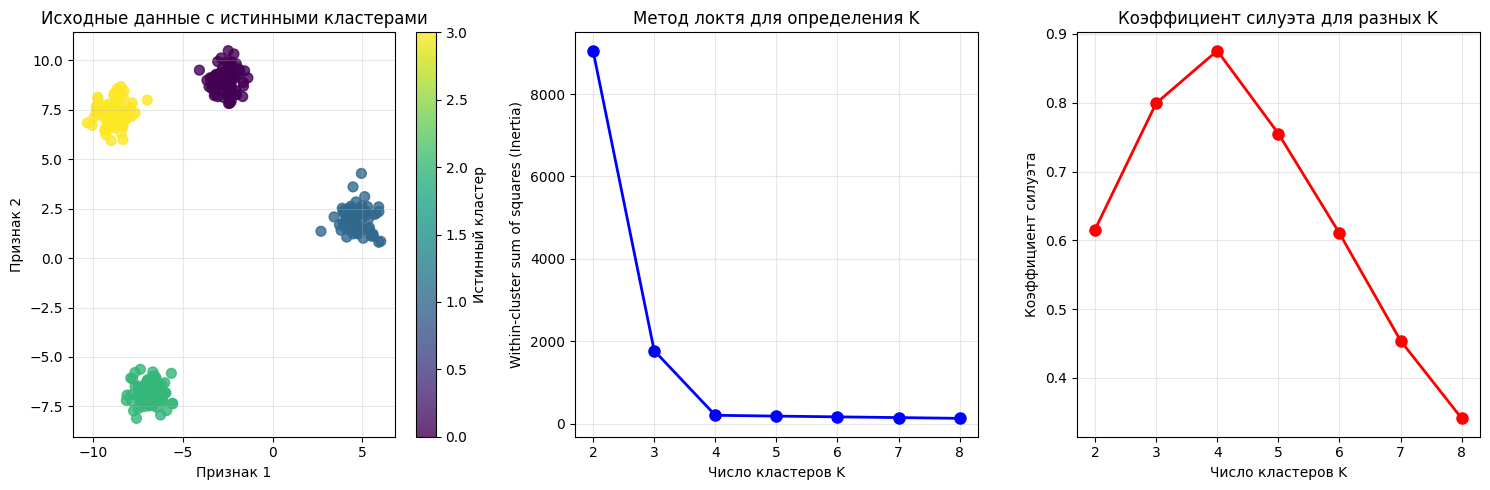


Оптимальное число кластеров: K=4


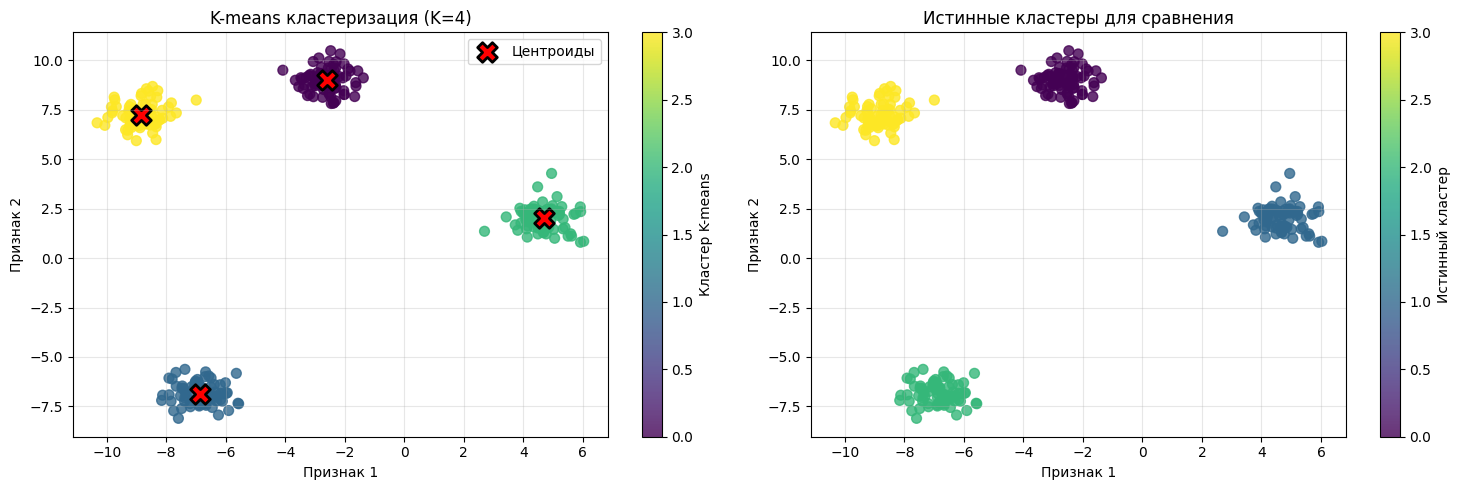

Коэффициент силуэта для K-means: 0.876

ПРИМЕНЕНИЕ МЕТОДА DBSCAN
Экспериментируем с параметрами DBSCAN:
eps=0.3, min_samples=3: кластеров=13, шум=43, силуэт=0.041
eps=0.3, min_samples=4: кластеров=7, шум=66, силуэт=0.315
eps=0.3, min_samples=5: кластеров=5, шум=85, силуэт=0.339
eps=0.5, min_samples=3: кластеров=4, шум=7, силуэт=0.828
eps=0.5, min_samples=4: кластеров=5, шум=8, силуэт=0.675
eps=0.5, min_samples=5: кластеров=4, шум=13, силуэт=0.798
eps=0.7, min_samples=3: кластеров=4, шум=4, силуэт=0.834
eps=0.7, min_samples=4: кластеров=4, шум=4, силуэт=0.834
eps=0.7, min_samples=5: кластеров=4, шум=4, силуэт=0.834
eps=1.0, min_samples=3: кластеров=4, шум=1, силуэт=0.773
eps=1.0, min_samples=4: кластеров=4, шум=1, силуэт=0.773
eps=1.0, min_samples=5: кластеров=4, шум=1, силуэт=0.773

Лучшие параметры: eps=0.7, min_samples=3
DBSCAN нашел 4 кластеров и 4 шумовых точек


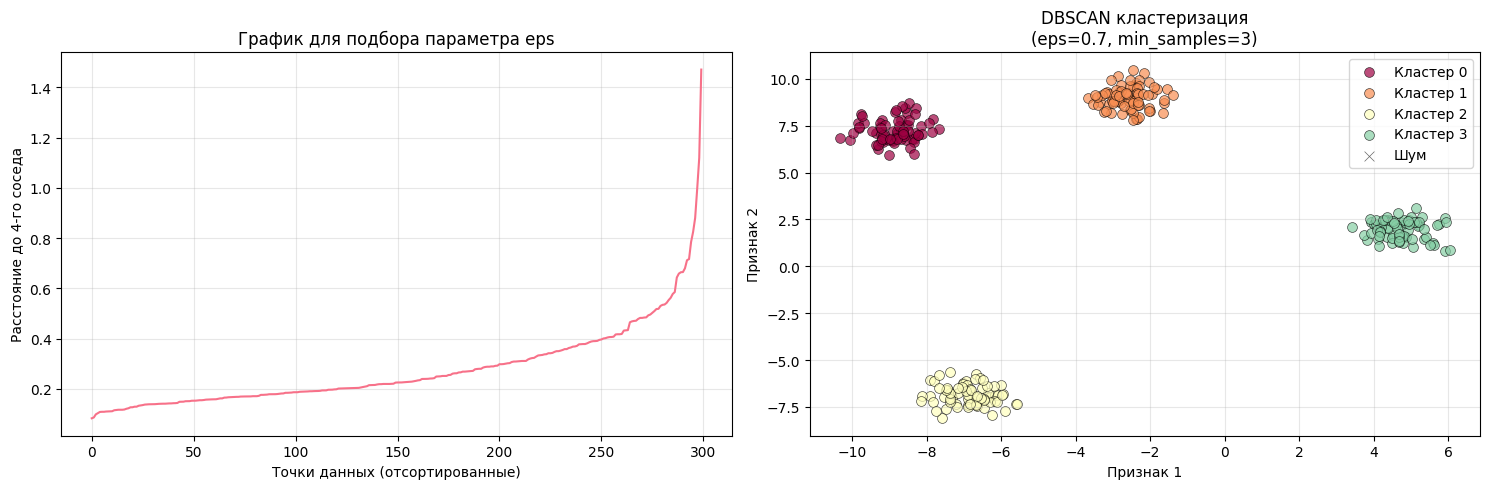


СРАВНЕНИЕ И АНАЛИЗ РЕЗУЛЬТАТОВ

СВОДКА РЕЗУЛЬТАТОВ:
Метод           Кластеров  Шум      Силуэт  
---------------------------------------------
Истинные        4          0        -       
K-means         4          0        0.876
DBSCAN          4          4        0.834


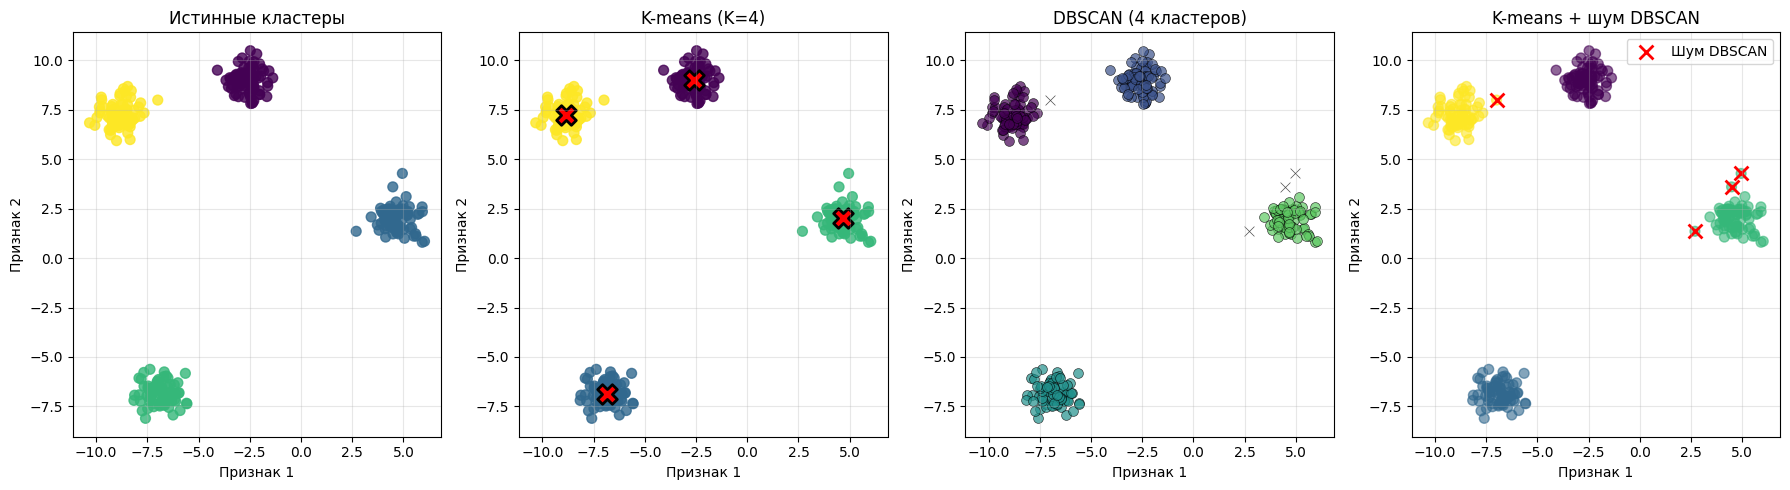

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use('default')
sns.set_palette("husl")

print("КЛАСТЕРИЗАЦИЯ НА СГЕНЕРИРОВАННЫХ ДАННЫХ \n")

print("СОЗДАНИЕ НАБОРА ДАННЫХ")

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60,
                       random_state=42, center_box=(-10, 10))

print(f"Размерность данных: {X.shape}")
print(f"Количество истинных кластеров: {len(np.unique(y_true))}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('Исходные данные с истинными кластерами')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Истинный кластер')
plt.grid(True, alpha=0.3)

print("\nПРИМЕНЕНИЕ МЕТОДА K-MEANS")

print("Подбор оптимального числа кластеров...")
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    print(f"K={k}: inertia={inertia[-1]:.2f}, silhouette={silhouette_avg:.3f}")

plt.subplot(1, 3, 2)
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров K')
plt.ylabel('Within-cluster sum of squares (Inertia)')
plt.title('Метод локтя для определения K')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров K')
plt.ylabel('Коэффициент силуэта')
plt.title('Коэффициент силуэта для разных K')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров: K={optimal_k}")

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans_optimal.fit_predict(X)
centroids = kmeans_optimal.cluster_centers_

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200,
           label='Центроиды', edgecolors='black', linewidth=2)
plt.title(f'K-means кластеризация (K={optimal_k})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.colorbar(scatter, label='Кластер K-means')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('Истинные кластеры для сравнения')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.colorbar(label='Истинный кластер')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

kmeans_silhouette = silhouette_score(X, y_kmeans)
print(f"Коэффициент силуэта для K-means: {kmeans_silhouette:.3f}")

print("\nПРИМЕНЕНИЕ МЕТОДА DBSCAN")

def find_optimal_eps(X, k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    distances = np.sort(distances[:, k-1], axis=0)
    return distances

k_min_samples = 4  # min_samples обычно = 2 * размерность данных
distances = find_optimal_eps(X, k_min_samples)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(distances)
plt.xlabel('Точки данных (отсортированные)')
plt.ylabel(f'Расстояние до {k_min_samples}-го соседа')
plt.title('График для подбора параметра eps')
plt.grid(True, alpha=0.3)


eps_candidates = [0.3, 0.5, 0.7, 1.0]
min_samples_candidates = [3, 4, 5]

print("Экспериментируем с параметрами DBSCAN:")

best_dbscan = None
best_silhouette = -1
best_params = {}

for eps in eps_candidates:
    for min_samples in min_samples_candidates:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        y_dbscan = dbscan.fit_predict(X)

        n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
        n_noise = list(y_dbscan).count(-1)

        if n_clusters > 1:
            silhouette_avg = silhouette_score(X, y_dbscan)
        else:
            silhouette_avg = -1

        print(f"eps={eps:.1f}, min_samples={min_samples}: "
              f"кластеров={n_clusters}, шум={n_noise}, силуэт={silhouette_avg:.3f}")

        if silhouette_avg > best_silhouette and n_clusters >= 2:
            best_silhouette = silhouette_avg
            best_dbscan = dbscan
            best_params = {'eps': eps, 'min_samples': min_samples}

print(f"\nЛучшие параметры: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
dbscan_optimal = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
y_dbscan = dbscan_optimal.fit_predict(X)

unique_labels = set(y_dbscan)
n_clusters = len(unique_labels) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

print(f"DBSCAN нашел {n_clusters} кластеров и {n_noise} шумовых точек")

plt.subplot(1, 2, 2)

core_samples_mask = np.zeros_like(y_dbscan, dtype=bool)
core_samples_mask[dbscan_optimal.core_sample_indices_] = True

colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Шумовые точки
        col = 'black'
        marker = 'x'
        label = 'Шум'
        alpha = 0.6
    else:
        marker = 'o'
        label = f'Кластер {k}'
        alpha = 0.7

    class_member_mask = (y_dbscan == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=50,
               label=label, alpha=alpha, edgecolors='black' if k != -1 else None,
               linewidth=0.5)

plt.title(f'DBSCAN кластеризация\n(eps={best_params["eps"]}, min_samples={best_params["min_samples"]})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСРАВНЕНИЕ И АНАЛИЗ РЕЗУЛЬТАТОВ")

print("\nСВОДКА РЕЗУЛЬТАТОВ:")
print(f"{'Метод':<15} {'Кластеров':<10} {'Шум':<8} {'Силуэт':<8}")
print("-" * 45)
print(f"{'Истинные':<15} {len(np.unique(y_true)):<10} {'0':<8} {'-':<8}")
print(f"{'K-means':<15} {optimal_k:<10} {'0':<8} {kmeans_silhouette:.3f}")
print(f"{'DBSCAN':<15} {n_clusters:<10} {n_noise:<8} {best_silhouette:.3f}")

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.8)
plt.title('Истинные кластеры')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)

# K-means
plt.subplot(1, 4, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200,
           edgecolors='black', linewidth=2)
plt.title(f'K-means (K={optimal_k})')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)

# DBSCAN
plt.subplot(1, 4, 3)
for k in unique_labels:
    if k == -1:
        col = 'black'
        marker = 'x'
    else:
        col = plt.cm.viridis(k / max(1, len(unique_labels)-1))
        marker = 'o'

    class_member_mask = (y_dbscan == k)
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=50,
               alpha=0.7, edgecolors='black' if k != -1 else None, linewidth=0.5)

plt.title(f'DBSCAN ({n_clusters} кластеров)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
comparison_scatter = plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis',
                                s=50, alpha=0.6)
plt.scatter(X[y_dbscan == -1, 0], X[y_dbscan == -1, 1],
           c='red', marker='x', s=100, linewidth=2, label='Шум DBSCAN')
plt.title('K-means + шум DBSCAN')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ И ОБРАБОТКА ДАННЫХ
Размер датасета: (344, 5)

Первые 5 строк:
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3               NaN              NaN                NaN          NaN     NaN
4              36.7             19.3              193.0       3450.0  FEMALE

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null   

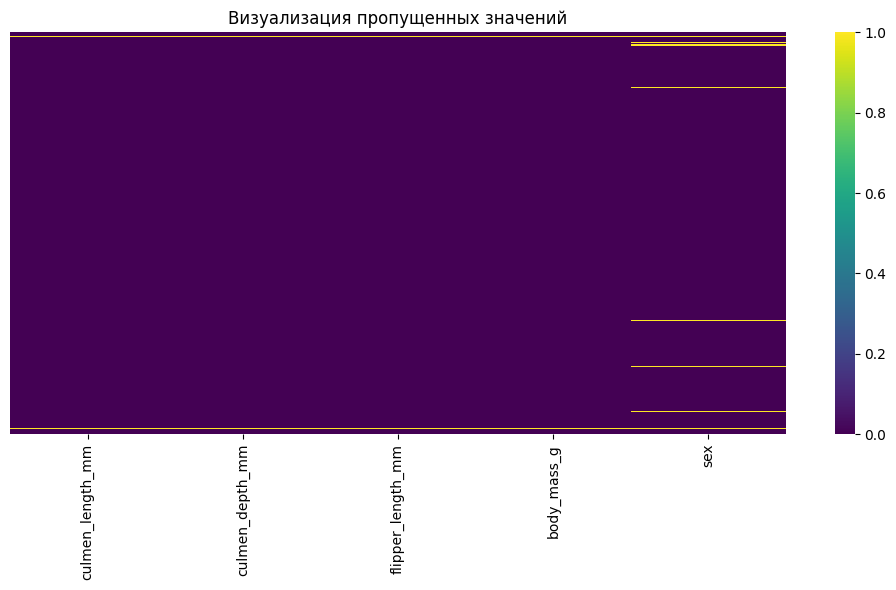

Поиск явных аномалий в данных:
Максимальные значения в каждом столбце:
culmen_length_mm: 59.6
culmen_depth_mm: 21.5
flipper_length_mm: 5000.0
body_mass_g: 6300.0

Строки с flipper_length_mm > 400:
   flipper_length_mm  body_mass_g
9             5000.0       4250.0

Строки с body_mass_g > 6000:
     flipper_length_mm  body_mass_g
237              221.0       6300.0
253              230.0       6050.0

Строки с отрицательными значениями:
    culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g   sex
14              34.6             21.1             -132.0       4400.0  MALE


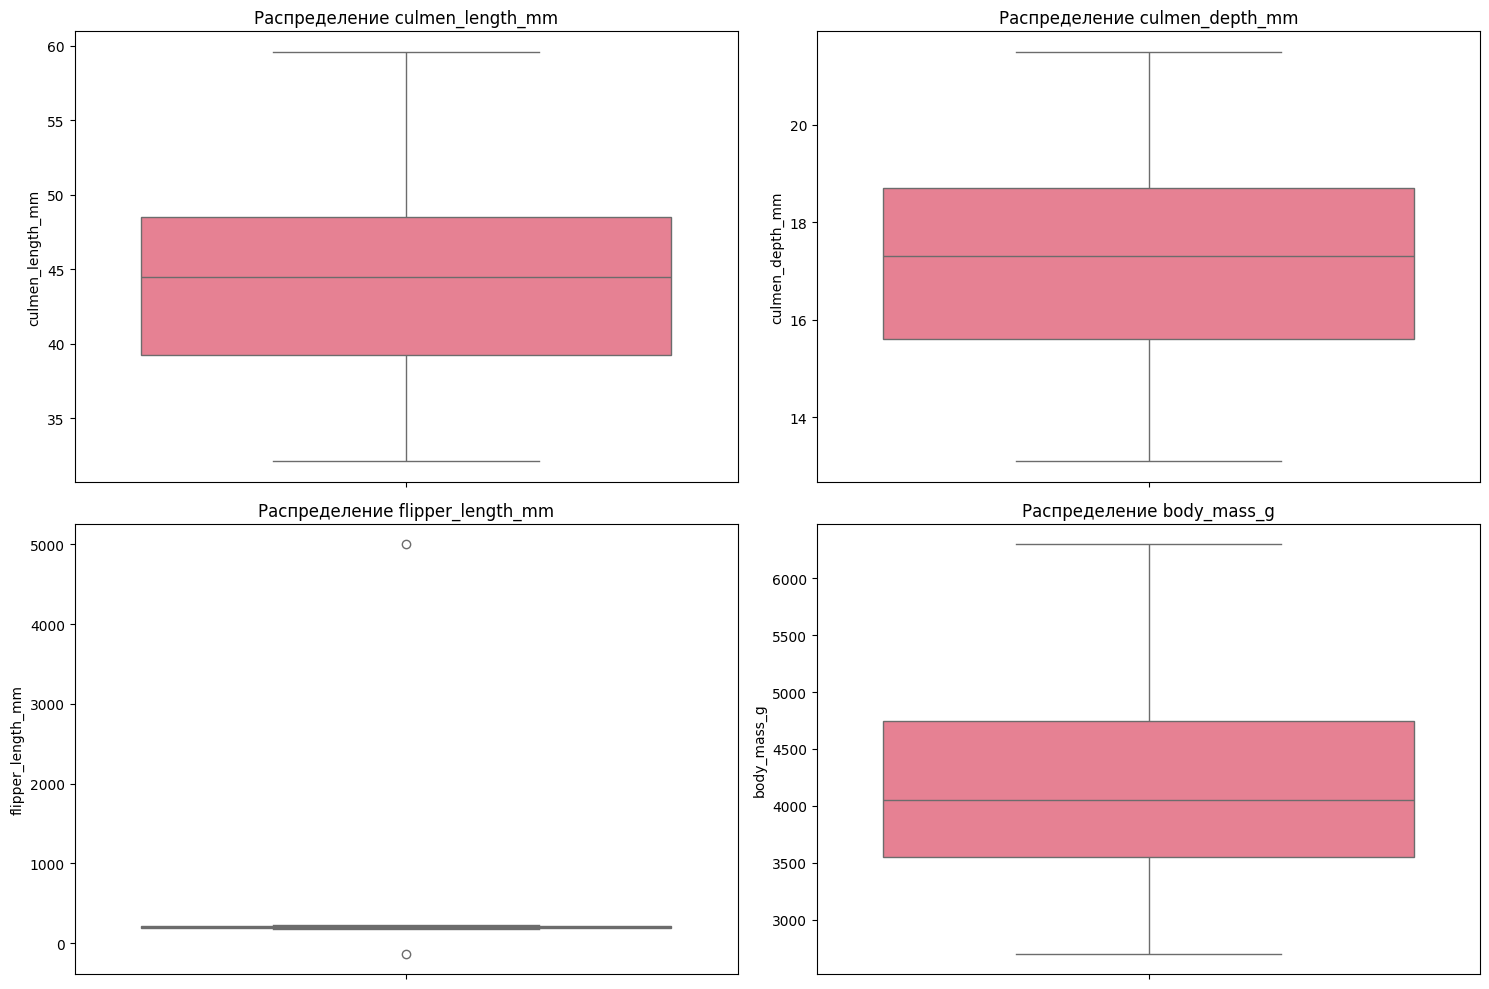

Заменено аномальных значений в culmen_length_mm: 0
Заменено аномальных значений в culmen_depth_mm: 0
Заменено аномальных значений в flipper_length_mm: 2
Заменено аномальных значений в body_mass_g: 0
Кодирование категориальных признаков...
Соответствие кодов категориям:
  0: FEMALE
  1: MALE

Результаты обработки:
Оставшиеся пропущенные значения: 0

Обновленная описательная статистика:
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count        344.000000       344.000000         344.000000   344.000000
mean          43.925000        17.152035         200.909884  4200.872093
std            5.443792         1.969060          14.013759   799.696532
min           32.100000        13.100000         172.000000  2700.000000
25%           39.275000        15.600000         190.000000  3550.000000
50%           44.450000        17.300000         197.000000  4050.000000
75%           48.500000        18.700000         213.000000  4750.000000
max           59.600000     

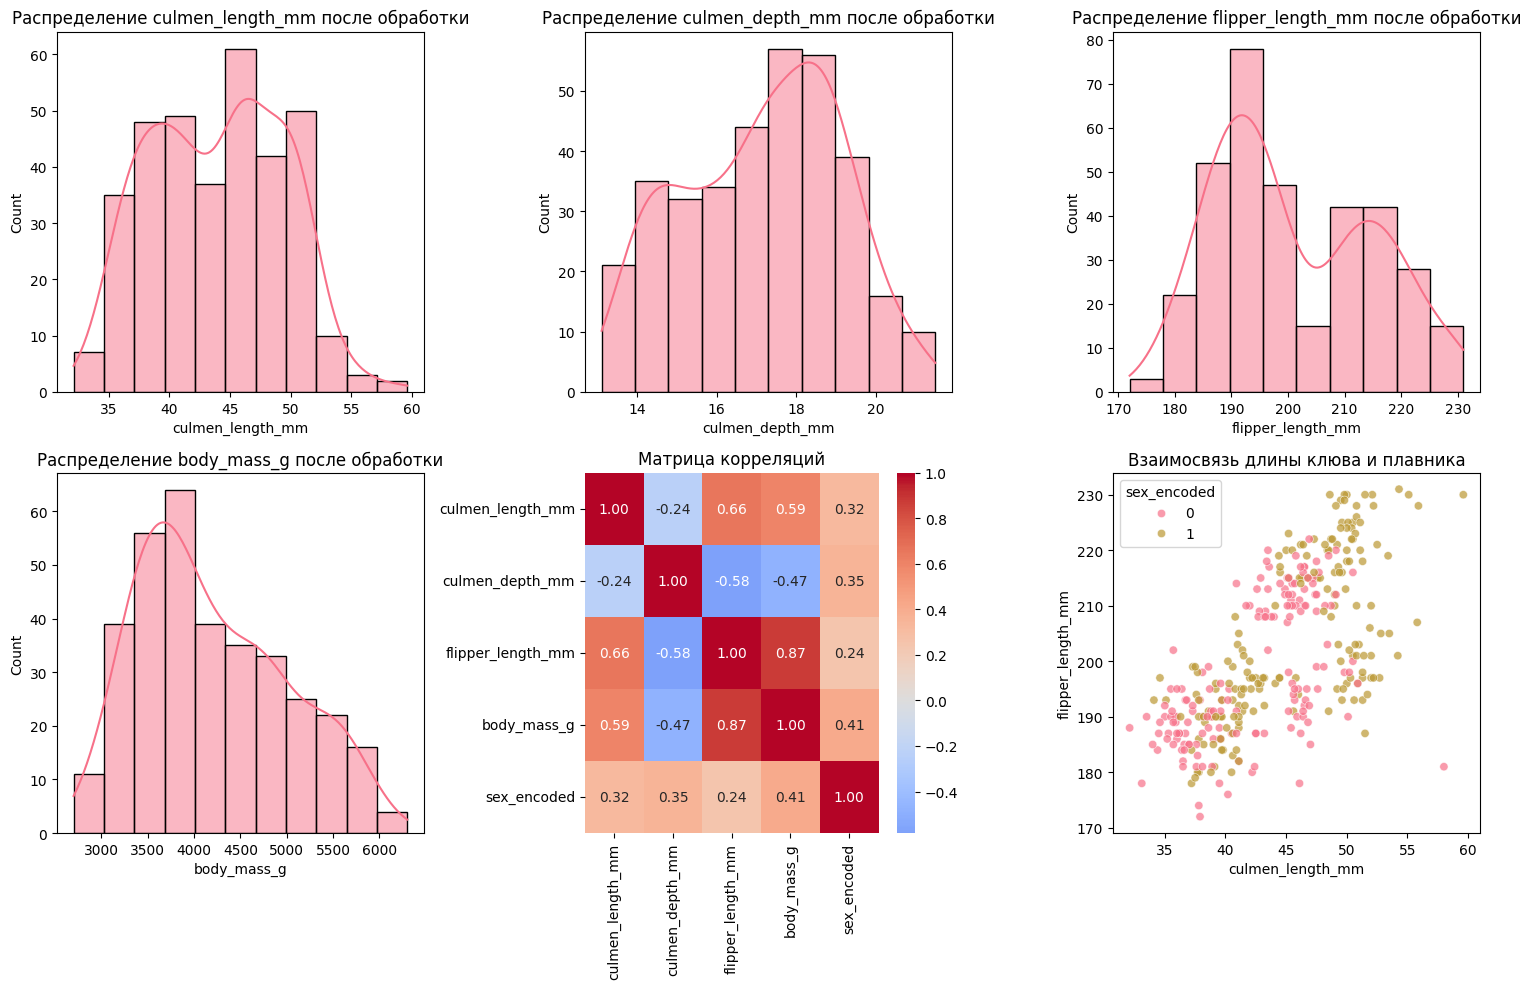

Данные до масштабирования (первые 5 строк):
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0             39.10             18.7              181.0       3750.0   
1             39.50             17.4              186.0       3800.0   
2             40.30             18.0              195.0       3250.0   
3             44.45             17.3              197.0       4050.0   
4             36.70             19.3              193.0       3450.0   

   sex_encoded  
0            1  
1            0  
2            0  
3            1  
4            0  

Статистика до масштабирования:
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
count        344.000000       344.000000         344.000000   344.000000   
mean          43.925000        17.152035         200.909884  4200.872093   
std            5.443792         1.969060          14.013759   799.696532   
min           32.100000        13.100000         172.000000  2700.000000   
25%      

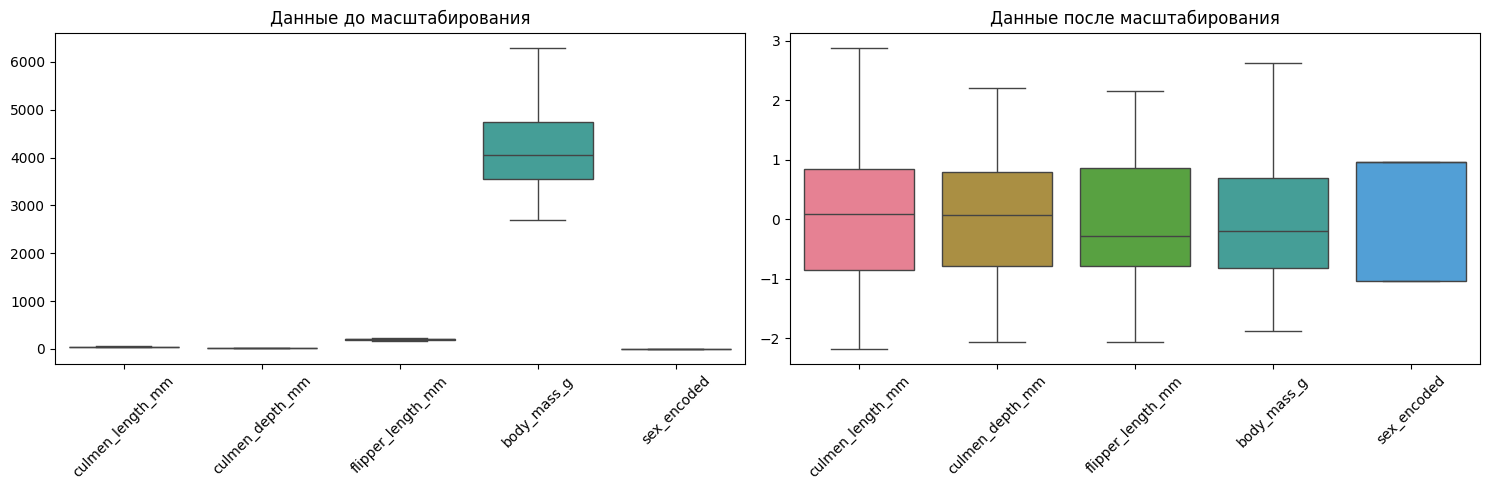

Исходный размер данных: (344, 5)
Размер после обработки: (344, 5)
Используемые признаки: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex_encoded']

Распределение закодированного признака пола:
sex_encoded
1    179
0    165
Name: count, dtype: int64

Корреляция признаков с полом:
sex_encoded          1.000000
body_mass_g          0.407107
culmen_depth_mm      0.354791
culmen_length_mm     0.322871
flipper_length_mm    0.243311
Name: sex_encoded, dtype: float64


In [12]:

import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ И ОБРАБОТКА ДАННЫХ")

url = 'https://raw.githubusercontent.com/ndanilova/Data_Analysis/main/lab2/penguins.csv'
df = pd.read_csv(url)

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nОписательная статистика после преобразования типов:")
print(df[numeric_columns].describe())

missing_data = df.isnull().sum()
print("Пропущенные значения по столбцам:")
print(missing_data[missing_data > 0])

print("\nУникальные значения в столбце 'sex':")
print(df['sex'].value_counts(dropna=False))

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Визуализация пропущенных значений')
plt.tight_layout()
plt.show()

print("Поиск явных аномалий в данных:")
print("Максимальные значения в каждом столбце:")
for col in numeric_columns:
    print(f"{col}: {df[col].max()}")

print("\nСтроки с flipper_length_mm > 400:")
print(df[df['flipper_length_mm'] > 400][['flipper_length_mm', 'body_mass_g']])

print("\nСтроки с body_mass_g > 6000:")
print(df[df['body_mass_g'] > 6000][['flipper_length_mm', 'body_mass_g']])

print("\nСтроки с отрицательными значениями:")
negative_flipper = df[df['flipper_length_mm'] < 0]
print(negative_flipper)

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

df_clean = df.copy()

reasonable_ranges = {
    'culmen_length_mm': (30, 70),
    'culmen_depth_mm': (10, 25),
    'flipper_length_mm': (150, 250),
    'body_mass_g': (2500, 7000)
}

# Замена явных аномалий на NaN
for col, (min_val, max_val) in reasonable_ranges.items():
    mask = (df_clean[col] < min_val) | (df_clean[col] > max_val)
    df_clean.loc[mask, col] = np.nan
    print(f"Заменено аномальных значений в {col}: {mask.sum()}")


numeric_imputer = SimpleImputer(strategy='median')
df_clean[numeric_columns] = numeric_imputer.fit_transform(df_clean[numeric_columns])


df_clean['sex'] = df_clean['sex'].replace('.', np.nan)
df_clean['sex'] = df_clean['sex'].replace('NA', np.nan)

categorical_imputer = SimpleImputer(strategy='most_frequent')
df_clean['sex'] = categorical_imputer.fit_transform(df_clean[['sex']]).ravel()

print("Кодирование категориальных признаков...")
label_encoder = LabelEncoder()
df_clean['sex_encoded'] = label_encoder.fit_transform(df_clean['sex'])

print("Соответствие кодов категориям:")
for i, category in enumerate(label_encoder.classes_):
    print(f"  {i}: {category}")

df_clean = df_clean.drop('sex', axis=1)

print("\nРезультаты обработки:")
print("Оставшиеся пропущенные значения:", df_clean.isnull().sum().sum())
print("\nОбновленная описательная статистика:")
print(df_clean[numeric_columns].describe())

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'Распределение {col} после обработки')

# Матрица корреляций
plt.subplot(2, 3, 5)
correlation_matrix = df_clean[numeric_columns + ['sex_encoded']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')

# Взаимосвязь ключевых признаков
plt.subplot(2, 3, 6)
sns.scatterplot(data=df_clean, x='culmen_length_mm', y='flipper_length_mm', hue='sex_encoded', alpha=0.7)
plt.title('Взаимосвязь длины клюва и плавника')

plt.tight_layout()
plt.show()

features_for_clustering = numeric_columns + ['sex_encoded']

# Создаем матрицу признаков
X_penguins = df_clean[features_for_clustering].copy()

print("Данные до масштабирования (первые 5 строк):")
print(X_penguins.head())

print("\nСтатистика до масштабирования:")
print(X_penguins.describe())

# Применяем StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_penguins)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("\nДанные после масштабирования (первые 5 строк):")
print(X_scaled_df.head())

print("\nСтатистика после масштабирования:")
print(X_scaled_df.describe())

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=X_penguins)
plt.title('Данные до масштабирования')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=X_scaled_df)
plt.title('Данные после масштабирования')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"Исходный размер данных: {df.shape}")
print(f"Размер после обработки: {X_scaled_df.shape}")
print(f"Используемые признаки: {features_for_clustering}")

print(f"\nРаспределение закодированного признака пола:")
print(df_clean['sex_encoded'].value_counts())

print("\nКорреляция признаков с полом:")
correlations = df_clean.corr()['sex_encoded'].sort_values(ascending=False)
print(correlations)


Определение оптимального числа кластеров...
K=2: inertia=914.72, silhouette=0.442
K=3: inertia=606.30, silhouette=0.445
K=4: inertia=415.50, silhouette=0.495
K=5: inertia=308.46, silhouette=0.507
K=6: inertia=241.40, silhouette=0.512
K=7: inertia=220.62, silhouette=0.467
K=8: inertia=200.04, silhouette=0.415
K=9: inertia=187.84, silhouette=0.357
K=10: inertia=177.88, silhouette=0.346


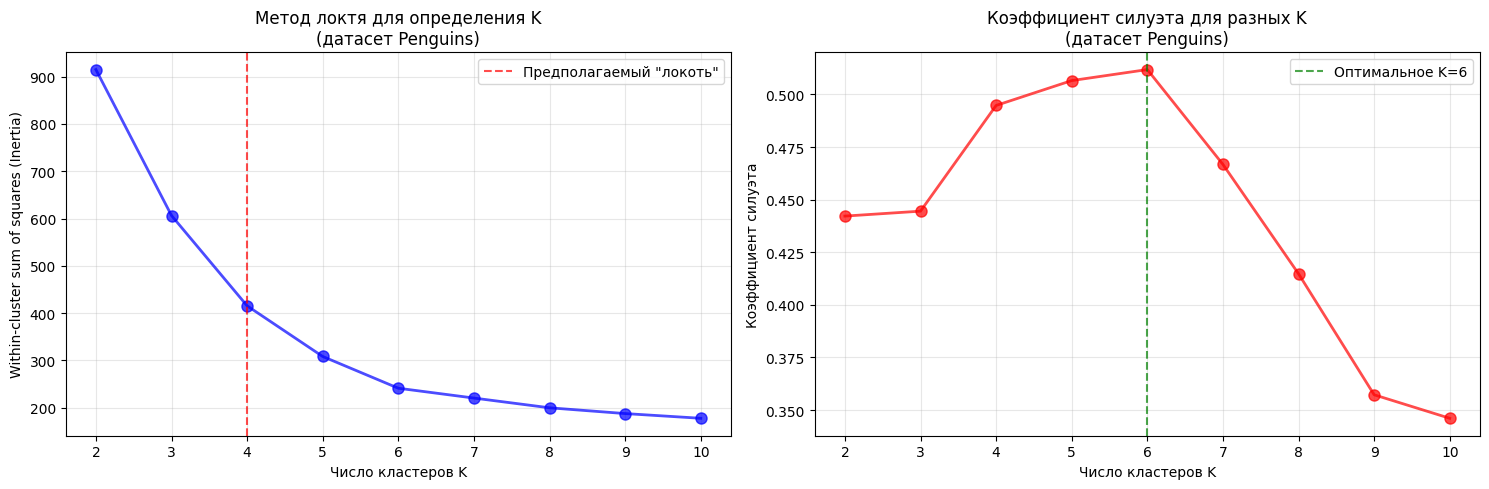


Оптимальное число кластеров: K=6

Применение K-means с K=6...
Коэффициент силуэта для K-means: 0.512

Распределение точек по кластерам:
Кластер 0: 78 точек (22.7%)
Кластер 1: 65 точек (18.9%)
Кластер 2: 77 точек (22.4%)
Кластер 3: 58 точек (16.9%)
Кластер 4: 29 точек (8.4%)
Кластер 5: 37 точек (10.8%)

Визуализация результатов с помощью PCA...


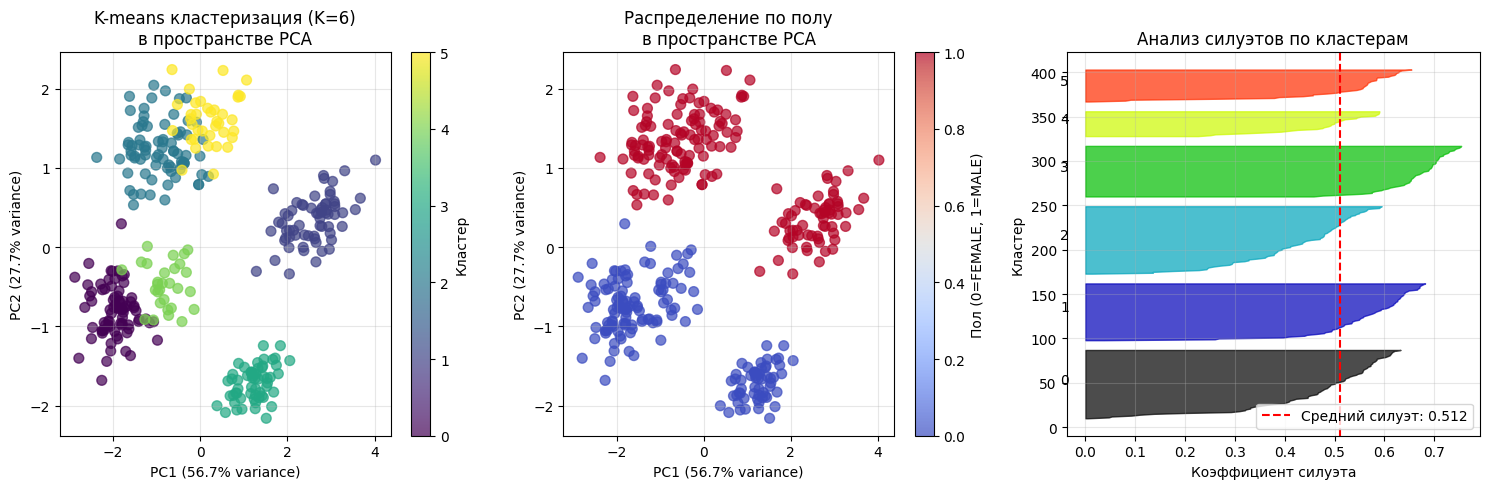


Анализ главных компонент:
Объясненная дисперсия PC1: 0.567
Объясненная дисперсия PC2: 0.277
Суммарная объясненная дисперсия: 0.844

Вклад признаков в главные компоненты:
                        PC1       PC2
culmen_length_mm   0.462610  0.168425
culmen_depth_mm   -0.339681  0.642530
flipper_length_mm  0.564716 -0.087458
body_mass_g        0.553299  0.057353
sex_encoded        0.213459  0.740169


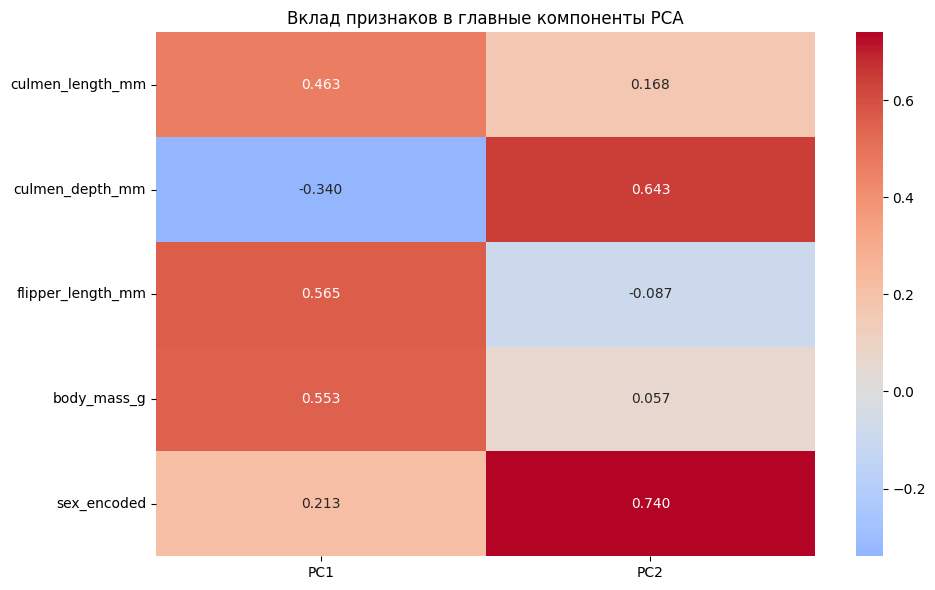


Анализ центроидов кластеров в исходном пространстве:
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0         37.580769        17.575641         187.666667  3363.141026   
1         49.236923        15.646154         221.184615  5429.615385   
2         40.138961        18.962338         191.857143  4008.116883   
3         45.563793        14.237931         212.706897  4679.741379   
4         47.310345        17.706897         192.758621  3569.827586   
5         50.624324        19.270270         199.945946  3953.378378   

    sex_encoded  
0  0.000000e+00  
1  1.000000e+00  
2  1.000000e+00  
3 -4.440892e-16  
4  3.330669e-16  
5  1.000000e+00  


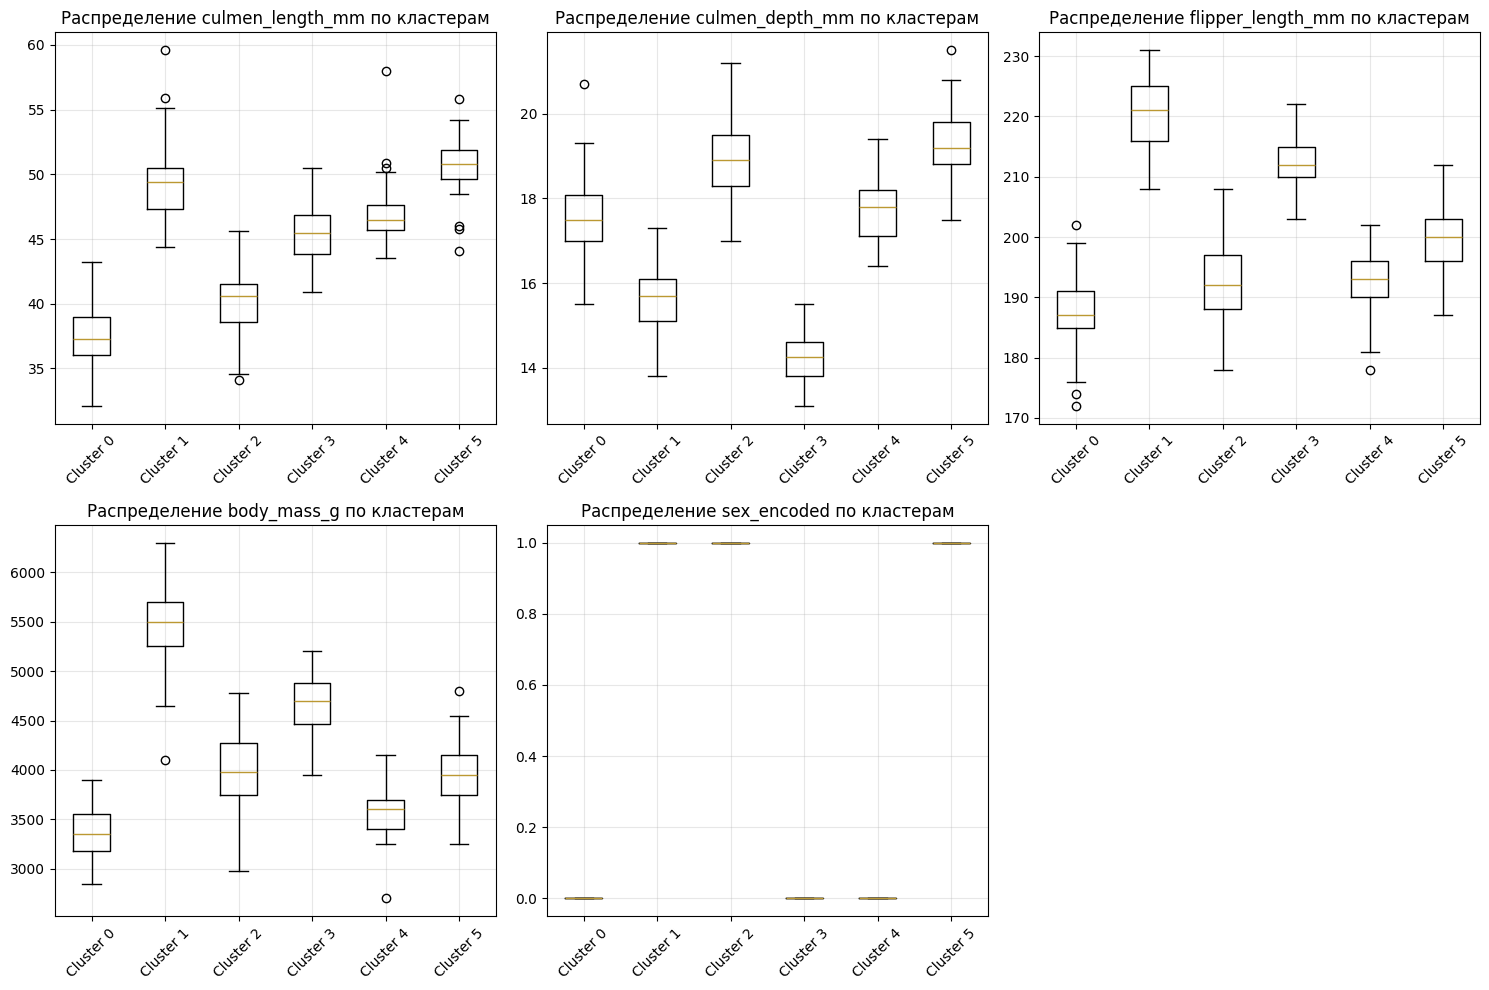


Средние значения признаков по кластерам:
         culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
Cluster                                                                      
0               37.580769        17.575641         187.666667  3363.141026   
1               49.236923        15.646154         221.184615  5429.615385   
2               40.138961        18.962338         191.857143  4008.116883   
3               45.563793        14.237931         212.706897  4679.741379   
4               47.310345        17.706897         192.758621  3569.827586   
5               50.624324        19.270270         199.945946  3953.378378   

         sex_encoded  
Cluster               
0                0.0  
1                1.0  
2                1.0  
3                0.0  
4                0.0  
5                1.0  


<Figure size 1200x800 with 0 Axes>

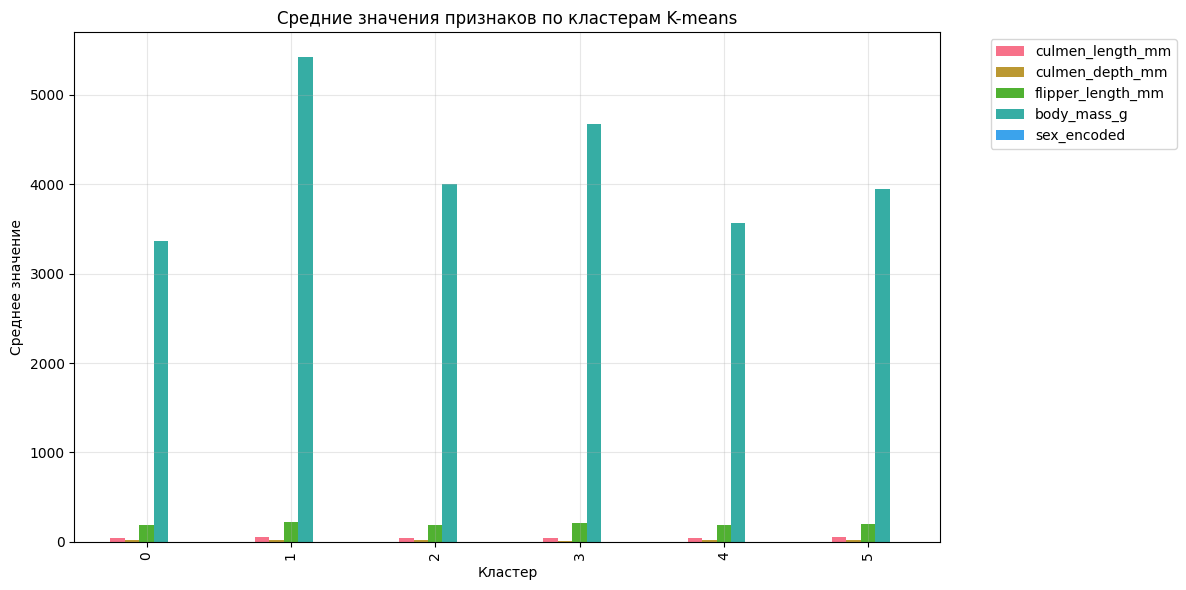

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# Метод локтя для определения оптимального K
print("Определение оптимального числа кластеров...")
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

    # Коэффициент силуэта
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    print(f"K={k}: inertia={inertia[-1]:.2f}, silhouette={silhouette_avg:.3f}")

plt.figure(figsize=(15, 5))

# График метода локтя
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8, alpha=0.7)
plt.xlabel('Число кластеров K')
plt.ylabel('Within-cluster sum of squares (Inertia)')
plt.title('Метод локтя для определения K\n(датасет Penguins)')
plt.grid(True, alpha=0.3)

elbow_idx = 2
plt.axvline(x=k_range[elbow_idx], color='red', linestyle='--', alpha=0.7, label='Предполагаемый "локоть"')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8, alpha=0.7)
plt.xlabel('Число кластеров K')
plt.ylabel('Коэффициент силуэта')
plt.title('Коэффициент силуэта для разных K\n(датасет Penguins)')
plt.grid(True, alpha=0.3)

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
plt.axvline(x=optimal_k_silhouette, color='green', linestyle='--', alpha=0.7,
            label=f'Оптимальное K={optimal_k_silhouette}')
plt.legend()

plt.tight_layout()
plt.show()
optimal_k = optimal_k_silhouette
print(f"\nОптимальное число кластеров: K={optimal_k}")

print(f"\nПрименение K-means с K={optimal_k}...")
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans_penguins = kmeans_optimal.fit_predict(X_scaled)
centroids_penguins = kmeans_optimal.cluster_centers_

kmeans_silhouette_penguins = silhouette_score(X_scaled, y_kmeans_penguins)
print(f"Коэффициент силуэта для K-means: {kmeans_silhouette_penguins:.3f}")

unique, counts = np.unique(y_kmeans_penguins, return_counts=True)
print("\nРаспределение точек по кластерам:")
for cluster, count in zip(unique, counts):
    print(f"Кластер {cluster}: {count} точек ({count/len(y_kmeans_penguins)*100:.1f}%)")

print("\nВизуализация результатов с помощью PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = y_kmeans_penguins
pca_df['sex_encoded'] = df_clean['sex_encoded'].values

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'],
                     cmap='viridis', s=50, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-means кластеризация (K={optimal_k})\nв пространстве PCA')
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
scatter_sex = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['sex_encoded'],
                         cmap='coolwarm', s=50, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Распределение по полу\nв пространстве PCA')
plt.colorbar(scatter_sex, label='Пол (0=FEMALE, 1=MALE)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
silhouette_vals = silhouette_samples(X_scaled, y_kmeans_penguins)
y_lower = 10

for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[y_kmeans_penguins == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=kmeans_silhouette_penguins, color="red", linestyle="--",
            label=f'Средний силуэт: {kmeans_silhouette_penguins:.3f}')
plt.title('Анализ силуэтов по кластерам')
plt.xlabel('Коэффициент силуэта')
plt.ylabel('Кластер')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nАнализ главных компонент:")
print(f"Объясненная дисперсия PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Объясненная дисперсия PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Суммарная объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

print("\nВклад признаков в главные компоненты:")
pca_components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_for_clustering
)
print(pca_components_df)

plt.figure(figsize=(10, 6))
sns.heatmap(pca_components_df, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Вклад признаков в главные компоненты PCA')
plt.tight_layout()
plt.show()

print("\nАнализ центроидов кластеров в исходном пространстве:")
centroids_original = scaler.inverse_transform(centroids_penguins)
centroids_df = pd.DataFrame(centroids_original, columns=features_for_clustering)
print(centroids_df)

# Визуализация характеристик кластеров
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_for_clustering, 1):
    plt.subplot(2, 3, i)

    # Boxplot распределения по кластерам
    cluster_data = []
    for cluster in range(optimal_k):
        cluster_values = df_clean[feature][y_kmeans_penguins == cluster]
        cluster_data.append(cluster_values)

    plt.boxplot(cluster_data, labels=[f'Cluster {i}' for i in range(optimal_k)])
    plt.title(f'Распределение {feature} по кластерам')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСредние значения признаков по кластерам:")
cluster_means = df_clean.copy()
cluster_means['Cluster'] = y_kmeans_penguins
cluster_summary = cluster_means.groupby('Cluster')[features_for_clustering].mean()
print(cluster_summary)

plt.figure(figsize=(12, 8))
cluster_summary_plot = cluster_summary.copy()
cluster_summary_plot.plot(kind='bar', figsize=(12, 6))
plt.title('Средние значения признаков по кластерам K-means')
plt.xlabel('Кластер')
plt.ylabel('Среднее значение')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Подбор параметра eps...
Экспериментируем с параметрами DBSCAN:
eps=0.5, min_samples=8: кластеров=6, шум=151, силуэт=0.093
eps=0.5, min_samples=10: кластеров=4, шум=202, силуэт=0.010
eps=0.5, min_samples=12: кластеров=5, шум=227, силуэт=-0.118
eps=0.5, min_samples=15: кластеров=1, шум=314, силуэт=-1.000
eps=0.7, min_samples=8: кластеров=5, шум=32, силуэт=0.441
eps=0.7, min_samples=10: кластеров=6, шум=40, силуэт=0.410
eps=0.7, min_samples=12: кластеров=6, шум=47, силуэт=0.398
eps=0.7, min_samples=15: кластеров=6, шум=61, силуэт=0.362
eps=0.9, min_samples=8: кластеров=4, шум=4, силуэт=0.489
eps=0.9, min_samples=10: кластеров=4, шум=4, силуэт=0.489
eps=0.9, min_samples=12: кластеров=4, шум=7, силуэт=0.482
eps=0.9, min_samples=15: кластеров=4, шум=9, силуэт=0.475
eps=1.1, min_samples=8: кластеров=4, шум=1, силуэт=0.482
eps=1.1, min_samples=10: кластеров=4, шум=1, силуэт=0.482
eps=1.1, min_samples=12: кластеров=4, шум=1, силуэт=0.482
eps=1.1, min_samples=15: кластеров=4, шум=1, силуэт=0.482

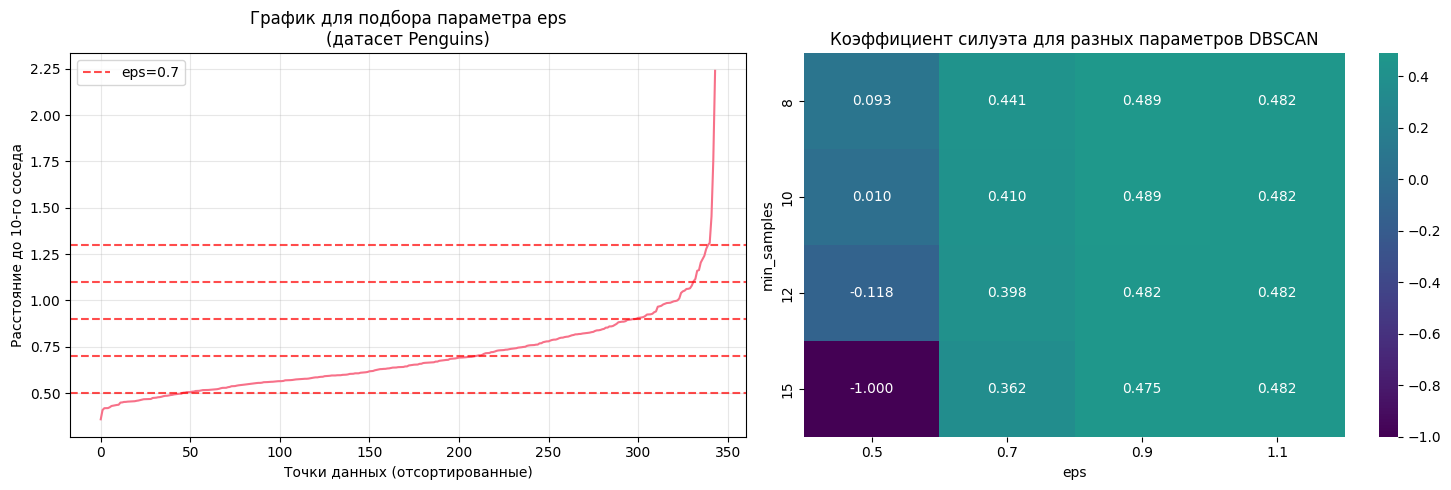


Лучшие параметры: eps=0.9, min_samples=8
DBSCAN нашел 4 кластеров и 4 шумовых точек
Коэффициент силуэта для DBSCAN: 0.489

Распределение точек по кластерам DBSCAN:
Шум: 4 точек (1.2%)
Кластер 0: 113 точек (32.8%)
Кластер 1: 105 точек (30.5%)
Кластер 2: 58 точек (16.9%)
Кластер 3: 64 точек (18.6%)


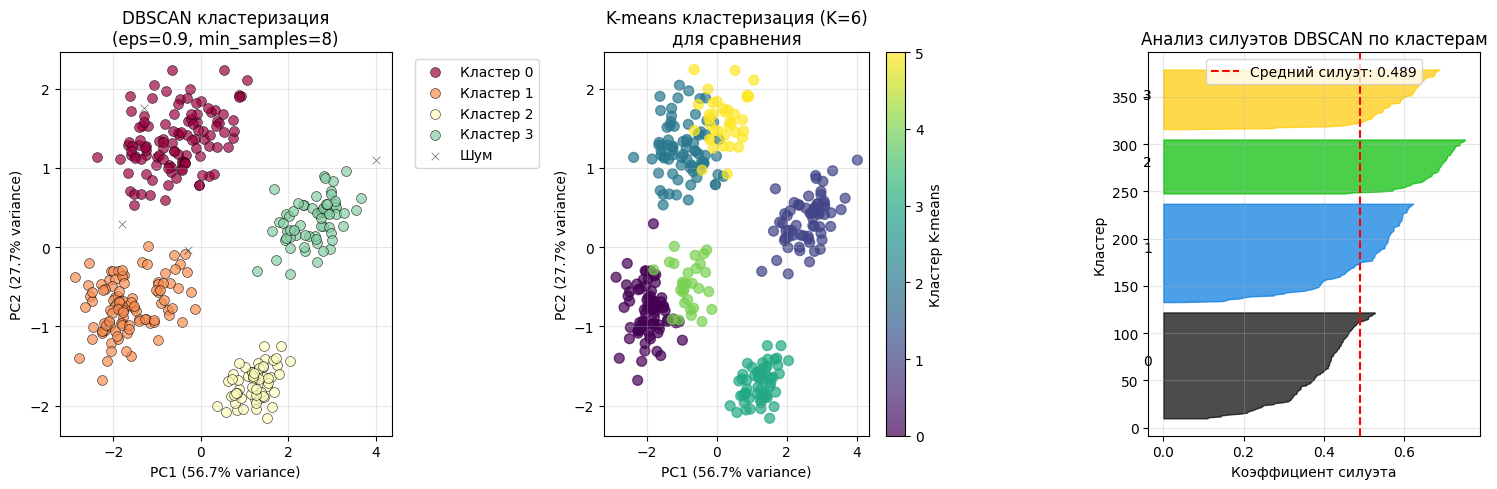

Средние значения признаков по кластерам DBSCAN:
                culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
DBSCAN_Cluster                                                         
0                      43.621239        19.044248         194.460177   
1                      40.054286        17.580000         189.104762   
2                      45.563793        14.237931         212.706897   
3                      49.075000        15.625000         221.046875   

                body_mass_g  sex_encoded  
DBSCAN_Cluster                            
0               3986.725664          1.0  
1               3411.904762          0.0  
2               4679.741379          0.0  
3               5419.921875          1.0  


<Figure size 1200x600 with 0 Axes>

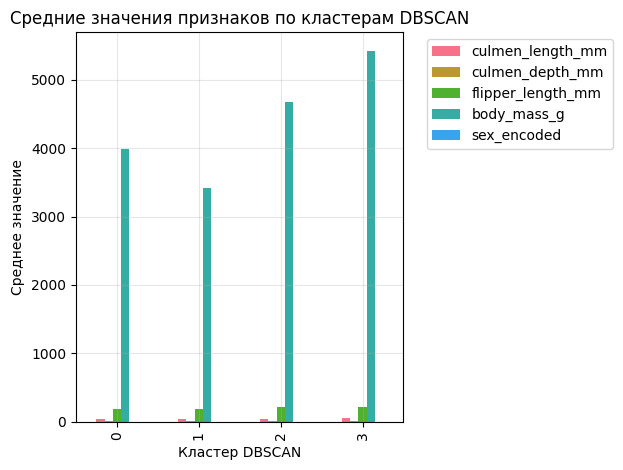


СВОДКА РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ:
Метод           Кластеров    Шум        Силуэт    
--------------------------------------------------
K-means         6            0          0.512
DBSCAN          4            4          0.489


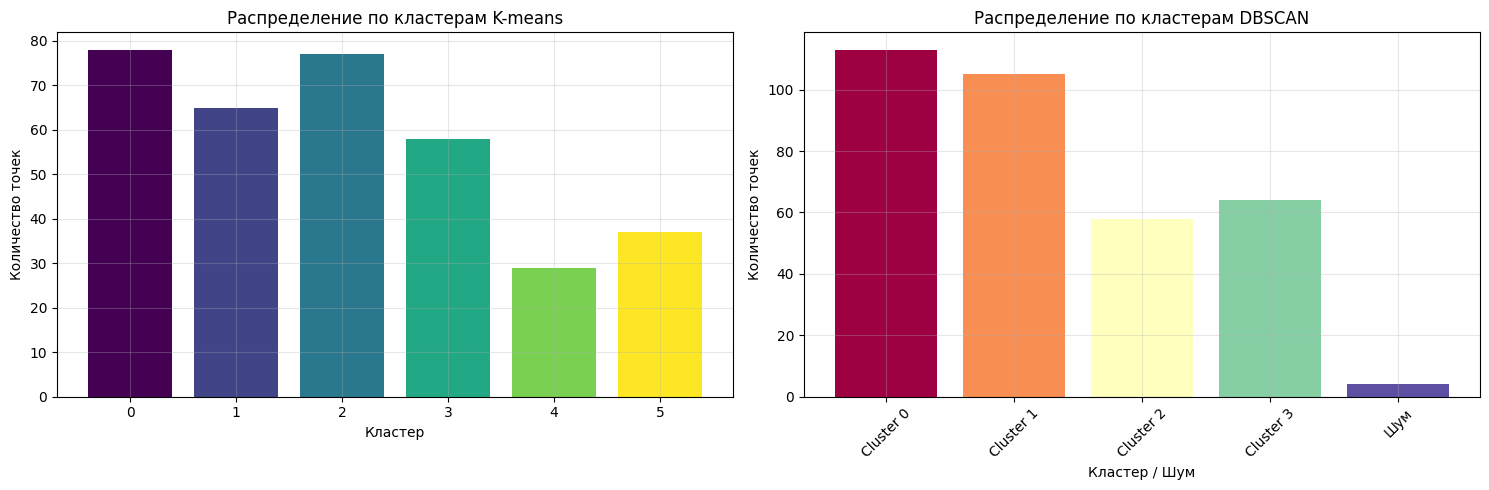

Таблица сопряженности кластеров K-means и DBSCAN:
col_0  -1   0   1   2   3
row_0                    
0       1   0  77   0   0
1       1   0   0   0  64
2       1  76   0   0   0
3       0   0   0  58   0
4       1   0  28   0   0
5       0  37   0   0   0


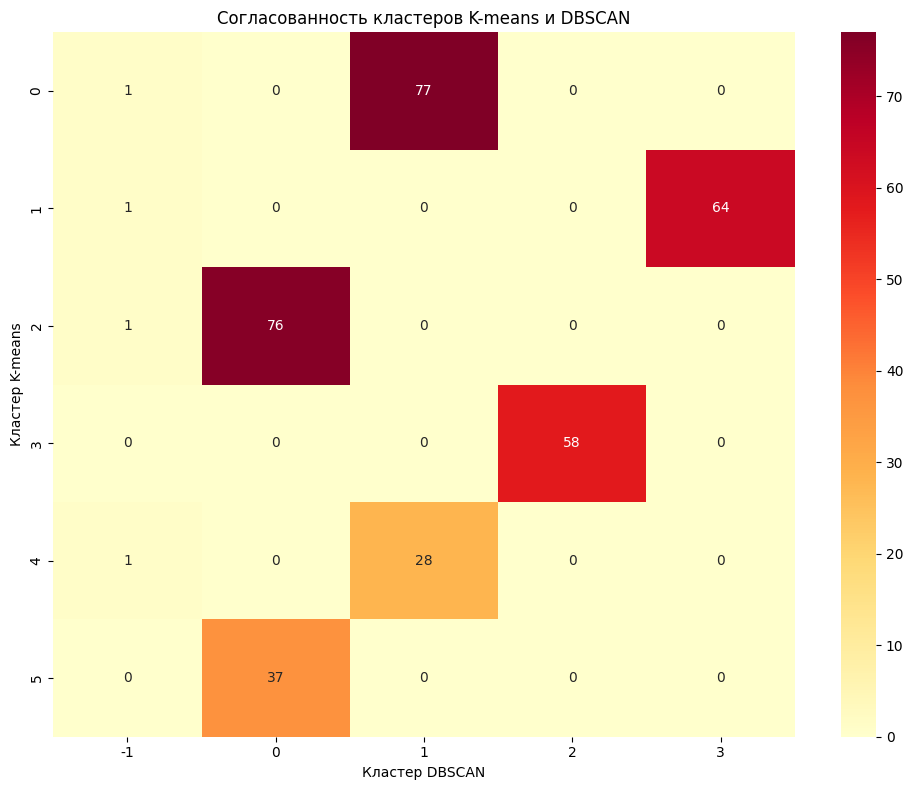


АНАЛИЗ ШУМОВЫХ ТОЧЕК DBSCAN (4 точек):
Статистика шумовых точек:
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
count          4.000000         4.000000           4.000000     4.000000   
mean          47.950000        19.150000         199.750000  4512.500000   
std           12.710494         2.053452          21.219095  1066.438778   
min           34.600000        17.000000         181.000000  3700.000000   
25%           38.350000        17.600000         188.500000  3850.000000   
50%           48.800000        19.250000         194.000000  4150.000000   
75%           58.400000        20.800000         205.250000  4812.500000   
max           59.600000        21.100000         230.000000  6050.000000   

       sex_encoded  
count      4.00000  
mean       0.50000  
std        0.57735  
min        0.00000  
25%        0.00000  
50%        0.50000  
75%        1.00000  
max        1.00000  

Проверка шумовых точек на аномалии:
culmen_length_mm: 0 выб

In [15]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

def find_optimal_eps(X, k):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    distances = np.sort(distances[:, k-1], axis=0)
    return distances

print("Подбор параметра eps...")
k_min_samples = 10  # min_samples обычно = 2 * размерность данных
distances = find_optimal_eps(X_scaled, k_min_samples)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(distances)
plt.xlabel('Точки данных (отсортированные)')
plt.ylabel(f'Расстояние до {k_min_samples}-го соседа')
plt.title('График для подбора параметра eps\n(датасет Penguins)')
plt.grid(True, alpha=0.3)

potential_eps = [0.5, 0.7, 0.9, 1.1, 1.3]
for eps in potential_eps:
    plt.axhline(y=eps, color='r', linestyle='--', alpha=0.7, label=f'eps={eps}' if eps == 0.7 else "")
plt.legend()

print("Экспериментируем с параметрами DBSCAN:")
eps_candidates = [0.5, 0.7, 0.9, 1.1]
min_samples_candidates = [8, 10, 12, 15]

best_dbscan = None
best_silhouette = -1
best_params = {}
results = []

for eps in eps_candidates:
    for min_samples in min_samples_candidates:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        y_dbscan = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
        n_noise = list(y_dbscan).count(-1)

        # Вычисляем силуэт только если есть более 1 кластера и не все точки - шум
        if n_clusters > 1 and n_noise < len(X_scaled) * 0.8:
            silhouette_avg = silhouette_score(X_scaled, y_dbscan)
        else:
            silhouette_avg = -1

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette_avg
        })

        print(f"eps={eps:.1f}, min_samples={min_samples}: "
              f"кластеров={n_clusters}, шум={n_noise}, силуэт={silhouette_avg:.3f}")

        if silhouette_avg > best_silhouette and n_clusters >= 2:
            best_silhouette = silhouette_avg
            best_dbscan = dbscan
            best_params = {'eps': eps, 'min_samples': min_samples}

results_df = pd.DataFrame(results)
pivot_table = results_df.pivot_table(values='silhouette',
                                    index='min_samples',
                                    columns='eps',
                                    aggfunc='first')

plt.subplot(1, 2, 2)
sns.heatmap(pivot_table, annot=True, cmap='viridis', center=0.4, fmt='.3f')
plt.title('Коэффициент силуэта для разных параметров DBSCAN')
plt.tight_layout()
plt.show()

print(f"\nЛучшие параметры: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
dbscan_optimal = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
y_dbscan_penguins = dbscan_optimal.fit_predict(X_scaled)

unique_labels = set(y_dbscan_penguins)
n_clusters_dbscan = len(unique_labels) - (1 if -1 in y_dbscan_penguins else 0)
n_noise_dbscan = list(y_dbscan_penguins).count(-1)

print(f"DBSCAN нашел {n_clusters_dbscan} кластеров и {n_noise_dbscan} шумовых точек")
print(f"Коэффициент силуэта для DBSCAN: {best_silhouette:.3f}")

unique_dbscan, counts_dbscan = np.unique(y_dbscan_penguins, return_counts=True)
print("\nРаспределение точек по кластерам DBSCAN:")
for label, count in zip(unique_dbscan, counts_dbscan):
    if label == -1:
        print(f"Шум: {count} точек ({count/len(y_dbscan_penguins)*100:.1f}%)")
    else:
        print(f"Кластер {label}: {count} точек ({count/len(y_dbscan_penguins)*100:.1f}%)")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Шумовые точки
        col = 'black'
        marker = 'x'
        label = 'Шум'
        alpha = 0.6
        s = 30
    else:
        marker = 'o'
        label = f'Кластер {k}'
        alpha = 0.7
        s = 50

    class_member_mask = (y_dbscan_penguins == k)
    xy = X_pca[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=s,
               label=label, alpha=alpha, edgecolors='black' if k != -1 else None,
               linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'DBSCAN кластеризация\n(eps={best_params["eps"]}, min_samples={best_params["min_samples"]})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Сравнение с K-means
plt.subplot(1, 3, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans_penguins,
                     cmap='viridis', s=50, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-means кластеризация (K=6)\nдля сравнения')
plt.colorbar(scatter, label='Кластер K-means')
plt.grid(True, alpha=0.3)

# Анализ силуэтов для DBSCAN
plt.subplot(1, 3, 3)
if n_clusters_dbscan > 1:
    silhouette_vals_dbscan = silhouette_samples(X_scaled, y_dbscan_penguins)
    y_lower = 10

    for i, label in enumerate([l for l in unique_labels if l != -1]):
        cluster_silhouette_vals = silhouette_vals_dbscan[y_dbscan_penguins == label]
        cluster_silhouette_vals.sort()
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters_dbscan)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, cluster_silhouette_vals,
                          facecolor=color, edgecolor=color, alpha=0.7)

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(label))
        y_lower = y_upper + 10

    plt.axvline(x=best_silhouette, color="red", linestyle="--",
                label=f'Средний силуэт: {best_silhouette:.3f}')
    plt.title('Анализ силуэтов DBSCAN по кластерам')
    plt.xlabel('Коэффициент силуэта')
    plt.ylabel('Кластер')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'Недостаточно кластеров\nдля анализа силуэтов',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Анализ силуэтов DBSCAN')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dbscan_clusters_df = df_clean.copy()
dbscan_clusters_df['DBSCAN_Cluster'] = y_dbscan_penguins

non_noise_clusters = [label for label in unique_labels if label != -1]

if non_noise_clusters:
    dbscan_summary = dbscan_clusters_df[dbscan_clusters_df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[features_for_clustering].mean()
    print("Средние значения признаков по кластерам DBSCAN:")
    print(dbscan_summary)

    plt.figure(figsize=(12, 6))
    dbscan_summary_plot = dbscan_summary.copy()
    dbscan_summary_plot.plot(kind='bar')
    plt.title('Средние значения признаков по кластерам DBSCAN')
    plt.xlabel('Кластер DBSCAN')
    plt.ylabel('Среднее значение')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("DBSCAN не нашел значимых кластеров (только шум)")

print("\nСВОДКА РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ:")
print(f"{'Метод':<15} {'Кластеров':<12} {'Шум':<10} {'Силуэт':<10}")
print("-" * 50)
print(f"{'K-means':<15} {optimal_k:<12} {'0':<10} {kmeans_silhouette_penguins:.3f}")
print(f"{'DBSCAN':<15} {n_clusters_dbscan:<12} {n_noise_dbscan:<10} {best_silhouette:.3f}")

plt.figure(figsize=(15, 5))

# Распределение по кластерам K-means
plt.subplot(1, 2, 1)
plt.bar(range(optimal_k), counts, color=plt.cm.viridis(np.linspace(0, 1, optimal_k)))
plt.xlabel('Кластер')
plt.ylabel('Количество точек')
plt.title('Распределение по кластерам K-means')
plt.grid(True, alpha=0.3)

# Распределение по кластерам DBSCAN
plt.subplot(1, 2, 2)
dbscan_counts = [counts_dbscan[i] for i in range(len(unique_dbscan)) if unique_dbscan[i] != -1]
dbscan_labels = [f'Cluster {label}' for label in unique_dbscan if label != -1]
if n_noise_dbscan > 0:
    dbscan_counts.append(n_noise_dbscan)
    dbscan_labels.append('Шум')

plt.bar(dbscan_labels, dbscan_counts, color=plt.cm.Spectral(np.linspace(0, 1, len(dbscan_counts))))
plt.xlabel('Кластер / Шум')
plt.ylabel('Количество точек')
plt.title('Распределение по кластерам DBSCAN')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


contingency_table = pd.crosstab(y_kmeans_penguins, y_dbscan_penguins)
print("Таблица сопряженности кластеров K-means и DBSCAN:")
print(contingency_table)

plt.figure(figsize=(10, 8))
sns.heatmap(contingency_table, annot=True, cmap='YlOrRd', fmt='d')
plt.title('Согласованность кластеров K-means и DBSCAN')
plt.xlabel('Кластер DBSCAN')
plt.ylabel('Кластер K-means')
plt.tight_layout()
plt.show()


if n_noise_dbscan > 0:
    print(f"\nАНАЛИЗ ШУМОВЫХ ТОЧЕК DBSCAN ({n_noise_dbscan} точек):")
    noise_points = dbscan_clusters_df[dbscan_clusters_df['DBSCAN_Cluster'] == -1]
    print("Статистика шумовых точек:")
    print(noise_points[features_for_clustering].describe())

    print("\nПроверка шумовых точек на аномалии:")
    for feature in features_for_clustering:
        q1 = df_clean[feature].quantile(0.25)
        q3 = df_clean[feature].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = noise_points[(noise_points[feature] < lower_bound) | (noise_points[feature] > upper_bound)]
        print(f"{feature}: {len(outliers)} выбросов из {n_noise_dbscan} шумовых точек")

